<a href="https://colab.research.google.com/github/ploypcr/Audio-Classification/blob/main/CNN_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#datasets from https://www.kaggle.com/datasets/mmoreaux/audio-cats-and-dogs

In [ ]:
import librosa, librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
from scipy.io import wavfile
import os
from tqdm import tqdm
import tensorflow as tf
import glob
import pandas as pd
import random

def spect(file):
    f, sr = librosa.load(file)
    padding = np.zeros(400000 - np.shape(f)[0])
    signal_length = np.concatenate([f, padding], axis=0)
    spectrogram = librosa.stft(signal_length)
    spectrogram = np.abs(spectrogram)
    return spectrogram

x_train = list()
x_test = list()
y_train = list()
y_test = list()

file_train = glob.glob('./train/*')
random.shuffle(file_train)

file_test = glob.glob('./test/*')
random.shuffle(file_test)
for f in file_train:
    x_train.append(spect(f))
    if 'cat' in f:
        y_train.append([0,1])
    else:
        y_train.append([1,0])

for f in file_test:
    x_test.append(spect(f))
    if 'cat' in f:
        y_test.append([0,1])
    else:
        y_test.append([1,0])

X_train = np.array(x_train)
Y_train = np.array(y_train)
X_test = np.array(x_test)
Y_test = np.array(y_test)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

print(X_test.shape,X_train.shape,Y_train.shape,Y_test.shape)

(67, 1025, 782, 1) (210, 1025, 782, 1) (210, 2) (67, 2)


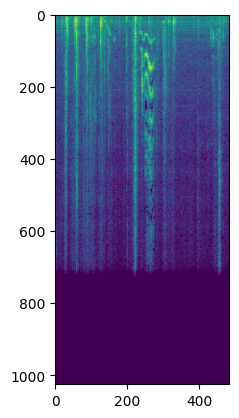

In [ ]:
f, sr = librosa.load('./train/cat_1.wav')
st = librosa.stft(f)
spectogram = np.abs(st)
plt.imshow(librosa.amplitude_to_db(spectogram))
Audio('./train/cat_1.wav')

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import SGD
model = keras.Sequential([
keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]),
keras.layers.MaxPooling2D(pool_size=(2, 2)),
keras.layers.Conv2D(32,(3,3) , activation='relu'),
keras.layers.MaxPooling2D(pool_size=(2,2)),
keras.layers.Dense(16),
keras.layers.Dense(8),
keras.layers.Flatten(),
keras.layers.Dense(2, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy'
, metrics= ['accuracy'])

model.fit(X_train,Y_train,epochs=5,validation_data=(X_test,Y_test),batch_size=16)

Epoch 1/5
14/14 [==============================] - 191s 14s/step - loss: 1.6679 - accuracy: 0.7238 - val_loss: 0.2943 - val_accuracy: 0.9104
Epoch 2/5
14/14 [==============================] - 190s 14s/step - loss: 0.1626 - accuracy: 0.9476 - val_loss: 0.6394 - val_accuracy: 0.8955
Epoch 3/5
14/14 [==============================] - 188s 13s/step - loss: 0.0800 - accuracy: 0.9714 - val_loss: 0.3174 - val_accuracy: 0.9403
Epoch 4/5
14/14 [==============================] - 189s 14s/step - loss: 0.0157 - accuracy: 1.0000 - val_loss: 0.4017 - val_accuracy: 0.9403
Epoch 5/5
14/14 [==============================] - 189s 14s/step - loss: 0.0075 - accuracy: 1.0000 - val_loss: 0.4412 - val_accuracy: 0.9254


In [ ]:
model.evaluate(X_test,Y_test)

3/3 [==============================] - 16s 4s/step - loss: 0.4412 - accuracy: 0.9254


[0.44115331768989563, 0.9253731369972229]

In [ ]:
y_predict = model.predict(X_test)
label = ['dog','cat']
print(Y_test.shape)


3/3 [==============================] - 15s 4s/step
(67, 2)


In [ ]:
print(X_test.shape)

(67, 1025, 782, 1)


In [ ]:
data = spect('./test/dog_barking_112.wav')
data = np.array(data)
print(data.shape)
data = data.reshape(1,data.shape[0],data.shape[1],1)
y_predict = model.predict(data)
print(label[y_predict.argmax()])

(1025, 782)
1/1 [==============================] - 0s 227ms/step
dog


In [ ]:
print(y_predict)

[[9.9999994e-01 8.4001283e-36]
 [7.5539780e-10 9.9999994e-01]
 [5.6865048e-07 9.9999934e-01]
 [9.9999994e-01 0.0000000e+00]
 [1.5562164e-04 9.9984431e-01]
 [9.9999994e-01 7.0606411e-16]
 [1.1240848e-09 9.9999994e-01]
 [3.2804731e-16 9.9999994e-01]
 [9.9999994e-01 1.6373219e-13]
 [1.6332851e-03 9.9836671e-01]
 [1.6365885e-09 9.9999994e-01]
 [9.9999994e-01 1.0673521e-09]
 [1.3829463e-06 9.9999851e-01]
 [9.9999994e-01 0.0000000e+00]
 [2.8262177e-01 7.1737826e-01]
 [1.0768972e-10 9.9999994e-01]
 [1.2868185e-01 8.7131804e-01]
 [9.9999994e-01 4.6548473e-10]
 [9.9999994e-01 1.2813915e-17]
 [5.2677637e-11 9.9999994e-01]
 [4.0206253e-15 9.9999994e-01]
 [9.9999994e-01 5.4331886e-18]
 [1.0100755e-11 9.9999994e-01]
 [4.2169137e-12 9.9999994e-01]
 [6.6640482e-10 9.9999994e-01]
 [1.4906101e-14 9.9999994e-01]
 [9.9999994e-01 9.5696580e-09]
 [2.7750610e-13 9.9999994e-01]
 [5.3260859e-08 9.9999994e-01]
 [9.9999994e-01 1.7416720e-34]
 [2.3601837e-12 9.9999994e-01]
 [1.2255430e-06 9.9999875e-01]
 [7.9246

In [ ]:
y_predicted_classes = np.argmax(y_predict, axis=1)
Y_test_classes = np.argmax(Y_test, axis=1)
Y_test_classes

array([0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1])

In [ ]:
cm = tf.math.confusion_matrix(labels=Y_test_classes,predictions=y_predicted_classes)
cm

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[24,  4],
       [ 1, 38]], dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

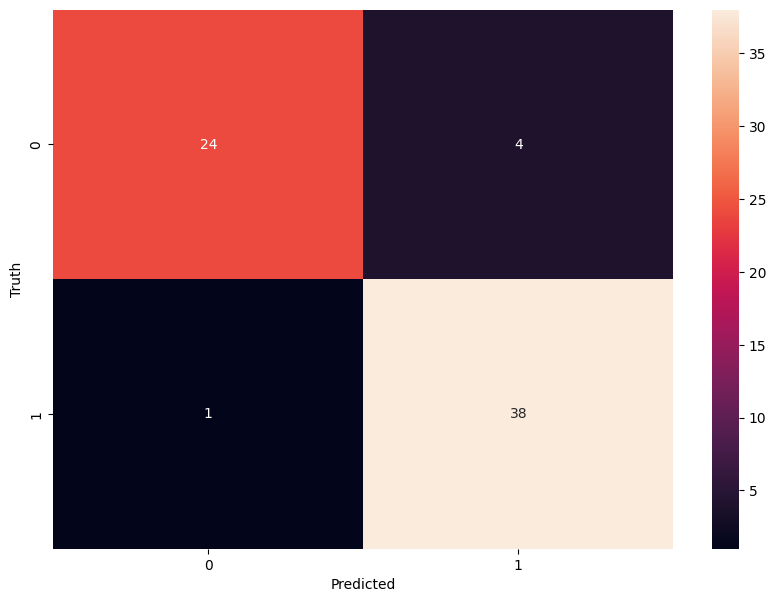

In [ ]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')